In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('dados_matriculas.xlsx')

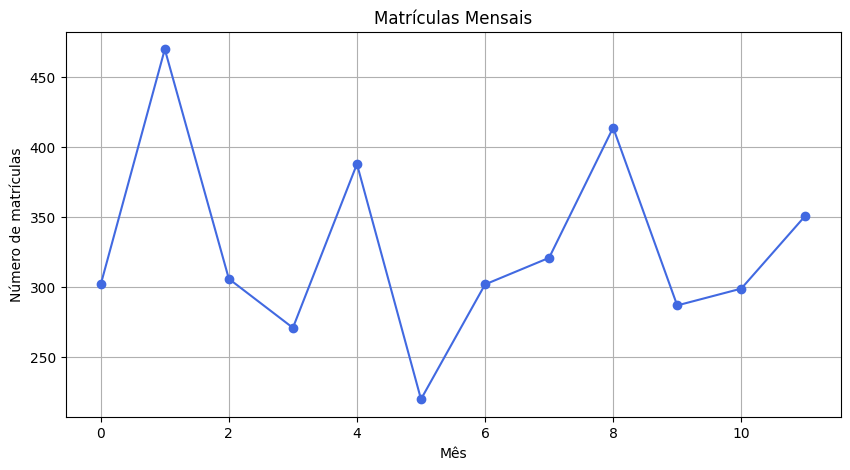

In [41]:
#Grafico de matriculas mensais
#Gráficos são contituidos por: titulo, legendas e os eixos X e Y
plt.figure(figsize=(10,5))
df['Matrículas'].plot(marker='o', linestyle='-', color='#4169E1') #Marker são os marcadores de onde ficam os valores no gráfico 
plt.title('Matrículas Mensais') #Título
plt.xlabel('Mês') #Eixo X
plt.ylabel('Número de matrículas') #Eixo y
plt.grid(True) #Grade por trás do gráfico
plt.show()

In [42]:
#Identificar o mês com o maior número de matrículas
maior_matricula = df['Matrículas'].max() #Puxa o valor máximo de Matrícula
indice_maior_matricula = df['Matrículas'].idxmax() #Puxa o index do maior valor de matrícula

print(maior_matricula)
print(indice_maior_matricula)

470
1


In [43]:
#Idenficar o mês com o menor número de matrícula
menor_matricula = df['Matrículas'].min()
indice_menor_matricula = df['Matrículas'].idxmin()

print(menor_matricula)
print(indice_menor_matricula)

220
5


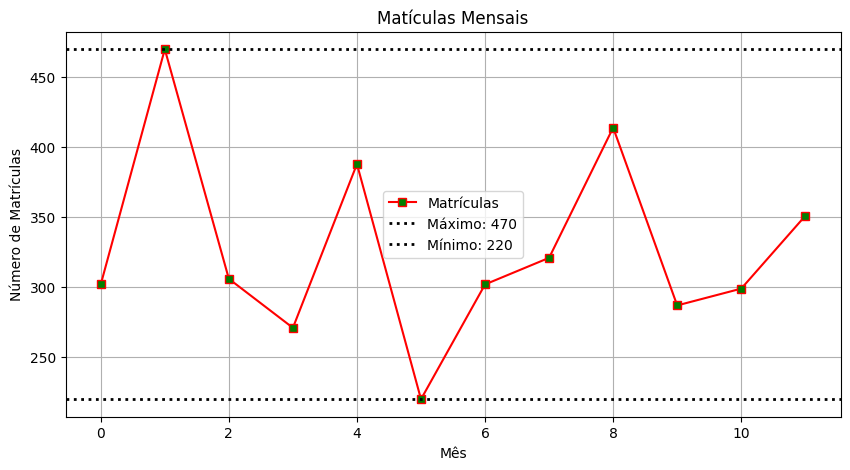

In [44]:
plt.figure(figsize=(10,5))
df['Matrículas'].plot(marker='s', linestyle='-', color='red', label='Matrículas', mfc='green')

#Informações de destaque
plt.axhline(y=maior_matricula,
            color='black',
            linestyle=':',
            linewidth=2,
            label=f'Máximo: {maior_matricula}'
            )

plt.axhline(y=menor_matricula,
            color='black',
            linestyle=':',
            linewidth=2,
            label=f'Mínimo: {menor_matricula}'
            )

plt.title('Matículas Mensais')
plt.xlabel('Mês')
plt.ylabel('Número de Matrículas')
plt.grid(True)
plt.legend()
plt.show()


In [45]:
#Média
media_matricula = df['Matrículas'].mean() #mean = média
print(media_matricula)

327.5833333333333


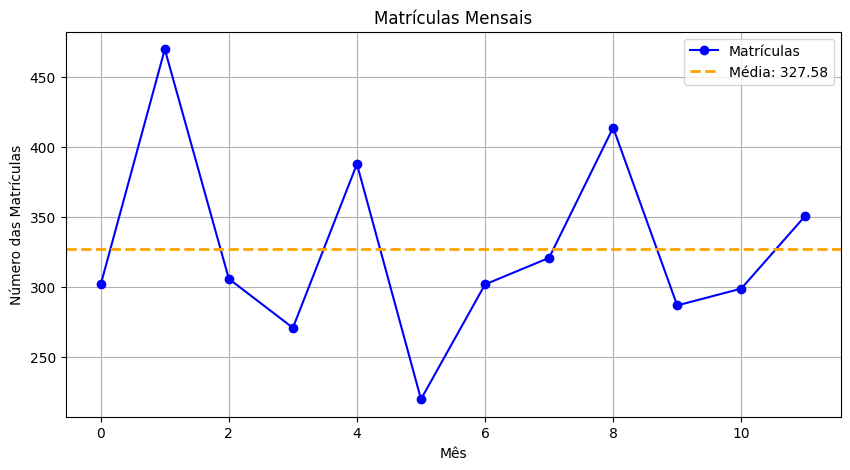

In [46]:
#Plotar o gráfico das mastrículas mensais e destacar a média
plt.figure(figsize=(10,5))
df['Matrículas'].plot(marker='o', linestyle='-', color='blue', label='Matrículas')

#Linha de destaque
plt.axhline(y=media_matricula, color='orange', linestyle='--', linewidth=2, label=f'Média: {media_matricula:.2f}')

plt.title('Matrículas Mensais')
plt.xlabel('Mês')
plt.ylabel('Número das Matrículas')
plt.grid(True)
plt.legend()
plt.show()

In [47]:
#Calcular a média das matrículas por trimestre (tendência)

#Passo 1. converter os dados de tempo para datetime
df['Mês'] = pd.to_datetime(df['Mês'])

#Passo 2. Definir a coluna de datas como indice
df.set_index('Mês', inplace=True)

#Passo 3. Calcular a média trimestal
#QE / 4 (Trimestre, 12/4 = 3)
#QS / 2 (Semestre, 12/2 = 6)
#Q / 3 (Quadrimestre, 12/3 = 4)
#A -> Anual 
#D -> Diário
#W -> Semanal
#H -> Horário
media_trimestral = df['Matrículas'].resample('QE').mean() #resample divide os dados por tipos de divisões pré-definidos exibidos nas linhas de cima

print(media_trimestral)

Mês
2022-03-31    359.333333
2022-06-30    293.000000
2022-09-30    345.666667
2022-12-31    312.333333
Freq: QE-DEC, Name: Matrículas, dtype: float64


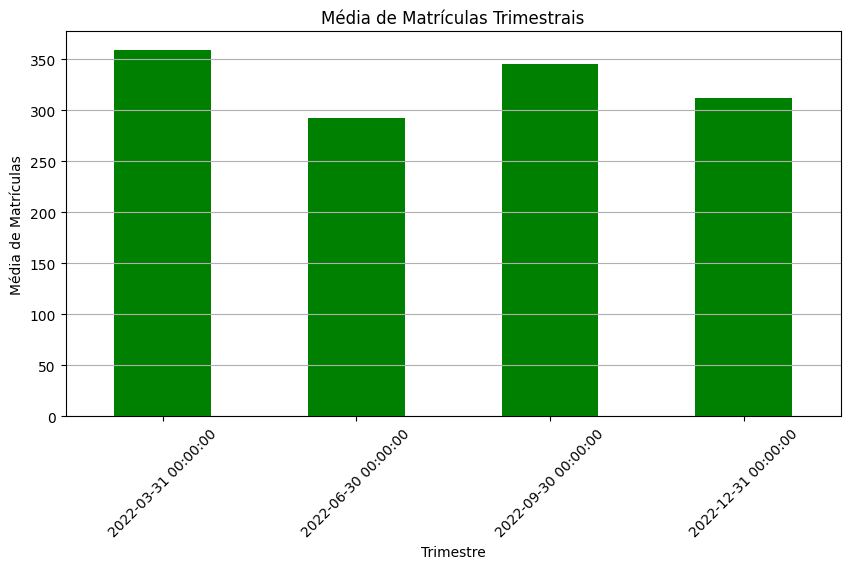

In [48]:
#Gráfico de linhas

plt.figure(figsize=(10,5))
media_trimestral.plot(kind='bar', color='green') #kind define o tipo de gráfico
plt.title("Média de Matrículas Trimestrais")
plt.xlabel('Trimestre')
plt.ylabel('Média de Matrículas')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [49]:
#Desvio simples (Valor escolhido - a média)
#1. Média

df['Matrículas'] - df['Matrículas'].mean()

Mês
2022-01-31    -25.583333
2022-02-28    142.416667
2022-03-31    -21.583333
2022-04-30    -56.583333
2022-05-31     60.416667
2022-06-30   -107.583333
2022-07-31    -25.583333
2022-08-31     -6.583333
2022-09-30     86.416667
2022-10-31    -40.583333
2022-11-30    -28.583333
2022-12-31     23.416667
Name: Matrículas, dtype: float64

In [50]:
#Variância
#1. Média
#2. Desvio simples
#3. Elevar o valor do desvio a 2
#4. Média do desvio elevado

#variacao = df['Matrículas'].pct_change() 
#pct change calcula a variação



In [51]:
#Desvio padrão
#1. Média
#2. Desvio simples
#3. Elevar o valor do desvio a 2
#4. Média do desvio elevado
#5. Variância
#6. Raiz quadrada da variância
df['Matrículas'].std()

np.float64(68.09546551894938)

In [52]:
#Calcular a variação percentual mensal

variacao = df['Matrículas'].pct_change() * 100 #O * 100 é para retornar em percentual


In [56]:
import seaborn as sn

tabela_variacao = pd.DataFrame({
    'Matrícula': df['Matrículas'],
    'Variação Percentual %': variacao
})

def colorir_variacao(valor): #Função que muda a cor do resultado exibido
    if valor > 0:
        color = 'green'
    elif valor < 0:
        color = 'red'
    else:
        color = 'white'
    return f'color: {color}'

tabela_variacao.style.map(colorir_variacao, subset=['Variação Percentual %']) #Muda a cor

,Matrícula,Variação Percentual %
Mês,,
2022-01-31 00:00:00,302,nan
2022-02-28 00:00:00,470,55.629139
2022-03-31 00:00:00,306,-34.893617
2022-04-30 00:00:00,271,-11.437908
2022-05-31 00:00:00,388,43.173432
2022-06-30 00:00:00,220,-43.298969
2022-07-31 00:00:00,302,37.272727
2022-08-31 00:00:00,321,6.291391
2022-09-30 00:00:00,414,28.971963
